# EnMAP Validity & Wavelength Analysis

For each EnMAP scene in `tests/test_payloads/`, this notebook:
1. Builds a `VendableEnmapHyperspectralDataset` via `EnmapDatasetBuilder`
2. Plots **per-band valid pixel percentage** from the validity cube
3. Visualizes **band numbers vs. exact center wavelengths** with VNIR/SWIR coloring

In [2]:
import sys, os, pathlib

# Ensure project root is on the path
PROJECT_ROOT = str(pathlib.Path(os.getcwd()).parent)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

from app.models.file_processing.sources import FileSourceConfig
from app.utils.dataset_builder.enmap_dataset_builder import EnmapDatasetBuilder
from app.models.hyperspectral_concepts.spectral_family import SpectralFamily

## 1. Discover test payloads & build vendables

In [3]:
TEST_PAYLOADS_DIR = os.path.join(PROJECT_ROOT, "tests", "test_payloads")

enmap_folders = sorted([
    d for d in os.listdir(TEST_PAYLOADS_DIR)
    if d.startswith("ENMAP") and os.path.isdir(os.path.join(TEST_PAYLOADS_DIR, d))
])

print(f"Found {len(enmap_folders)} EnMAP scenes:")
for f in enmap_folders:
    print(f"  - {f}")

Found 5 EnMAP scenes:
  - ENMAP01-____L2A-DT0000059367_20240128T063655Z_018_V010506_20260305T173243Z
  - ENMAP01-____L2A-DT0000118813_20250309T052400Z_002_V010506_20260305T174411Z
  - ENMAP01-____L2A-DT0000157567_20251013T061429Z_019_V010506_20260305T173019Z
  - ENMAP01-____L2A-DT0000169460_20251219T051408Z_014_V010506_20260305T173714Z
  - ENMAP01-____L2A-DT0000180781_20260227T052837Z_002_V010506_20260305T174233Z


In [4]:
def build_vendable(scene_folder: str):
    """Build a VendableEnmapHyperspectralDataset from a scene folder path."""
    config = FileSourceConfig(source_path=scene_folder)
    builder = EnmapDatasetBuilder(file_source_configuration=config)
    return builder.vend_dataset()


def compute_valid_pixel_pct(vendable) -> np.ndarray:
    """
    Returns a 1-D array of length n_bands with the percentage of
    spatially valid pixels per band, derived from the validity cube.
    """
    vc = vendable.validity_cube  # (n_bands, H, W), values 0 or 1
    n_pixels = vc.shape[1] * vc.shape[2]
    return (vc.sum(axis=(1, 2)) / n_pixels) * 100.0


def short_scene_label(folder_name: str) -> str:
    """Extract a compact label from an EnMAP folder name (date + orbit)."""
    parts = folder_name.split("_")
    date_str = parts[3][:8]
    orbit = parts[4]
    return f"{date_str}_{orbit}"

In [5]:
# Build all vendables (this reads large TIFs — may take a few minutes)
vendables = {}
for folder_name in enmap_folders:
    label = short_scene_label(folder_name)
    print(f"Building vendable for {label} ...")
    scene_path = os.path.join(TEST_PAYLOADS_DIR, folder_name)
    vendables[label] = build_vendable(scene_path)
    print(f"  -> cube shape: {vendables[label].normalized_hyperspectral_cube.shape}")

print(f"\nAll {len(vendables)} vendables built.")

Building vendable for _L2A-DT0000059367 ...
  -> cube shape: (224, 1179, 1320)
Building vendable for _L2A-DT0000118813 ...
  -> cube shape: (224, 1174, 1335)
Building vendable for _L2A-DT0000157567 ...
  -> cube shape: (224, 1174, 1346)
Building vendable for _L2A-DT0000169460 ...
  -> cube shape: (224, 1175, 1353)
Building vendable for _L2A-DT0000180781 ...
  -> cube shape: (224, 1173, 1326)

All 5 vendables built.


## 2. Per-band valid pixel percentage

One line per scene. X-axis = band index (0-223), Y-axis = % of spatial pixels that are valid in that band.

/var/folders/_5/16204pp15b5g4nzv_mhf6pg40000gn/T/ipykernel_28121/4097637439.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc="lower left")


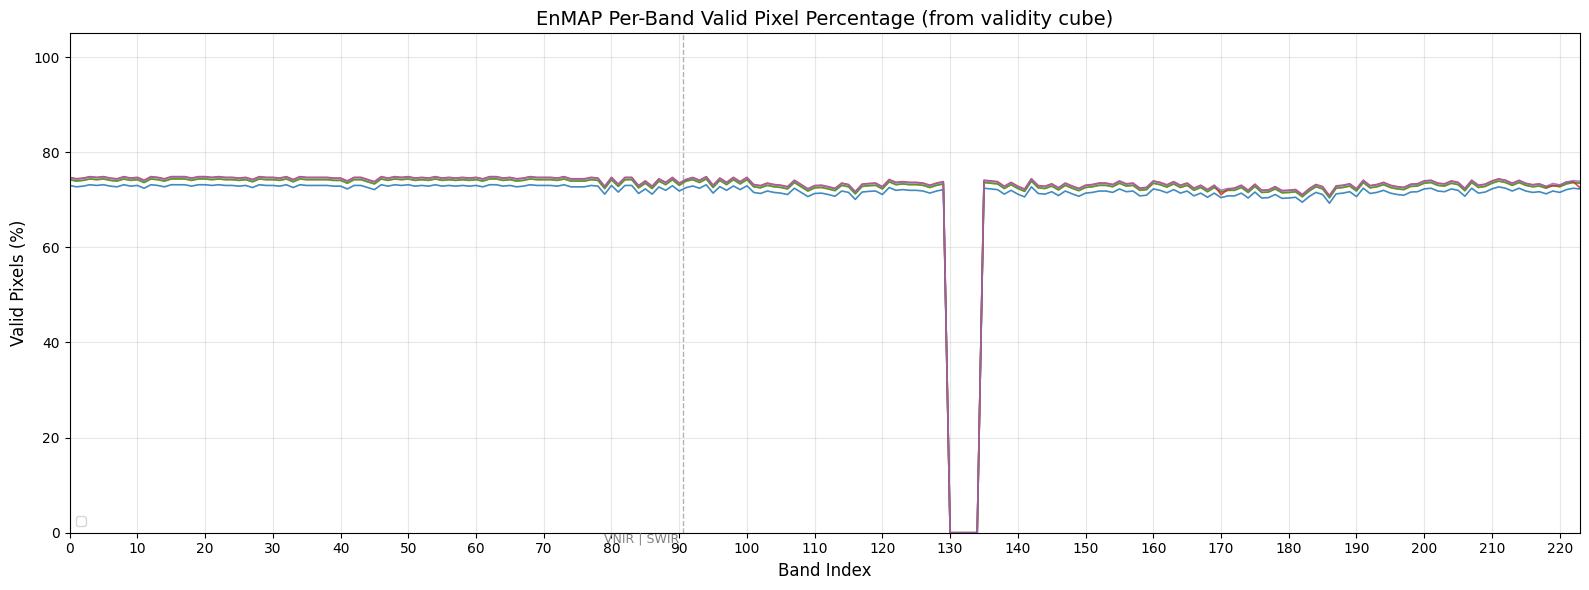

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))

cmap = plt.cm.tab10
for i, (label, v) in enumerate(vendables.items()):
    pct = compute_valid_pixel_pct(v)
    band_indices = np.arange(len(pct))
    ax.plot(band_indices, pct, label=label, color=cmap(i), linewidth=1.2, alpha=0.85)

# Mark the VNIR / SWIR boundary (band 91 is first SWIR)
first_vendable = next(iter(vendables.values()))
n_vnir = len(first_vendable.vnir_channel_indices)
ax.axvline(x=n_vnir - 0.5, color="grey", linestyle="--", linewidth=1, alpha=0.6)
ax.text(n_vnir - 1, ax.get_ylim()[0] + 1, "VNIR | SWIR", fontsize=9,
        ha="right", va="bottom", color="grey")

ax.set_xlabel("Band Index", fontsize=12)
ax.set_ylabel("Valid Pixels (%)", fontsize=12)
ax.set_title("EnMAP Per-Band Valid Pixel Percentage (from validity cube)", fontsize=14)
ax.legend(fontsize=9, loc="lower left")
ax.set_xlim(0, len(pct) - 1)
ax.set_ylim(0, 105)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(axis="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Band number vs. center wavelength

Scatter plot showing the exact wavelength (nm) for each of the 224 bands, colored by VNIR/SWIR detector. Uses data from the first vendable (wavelengths are identical across scenes).

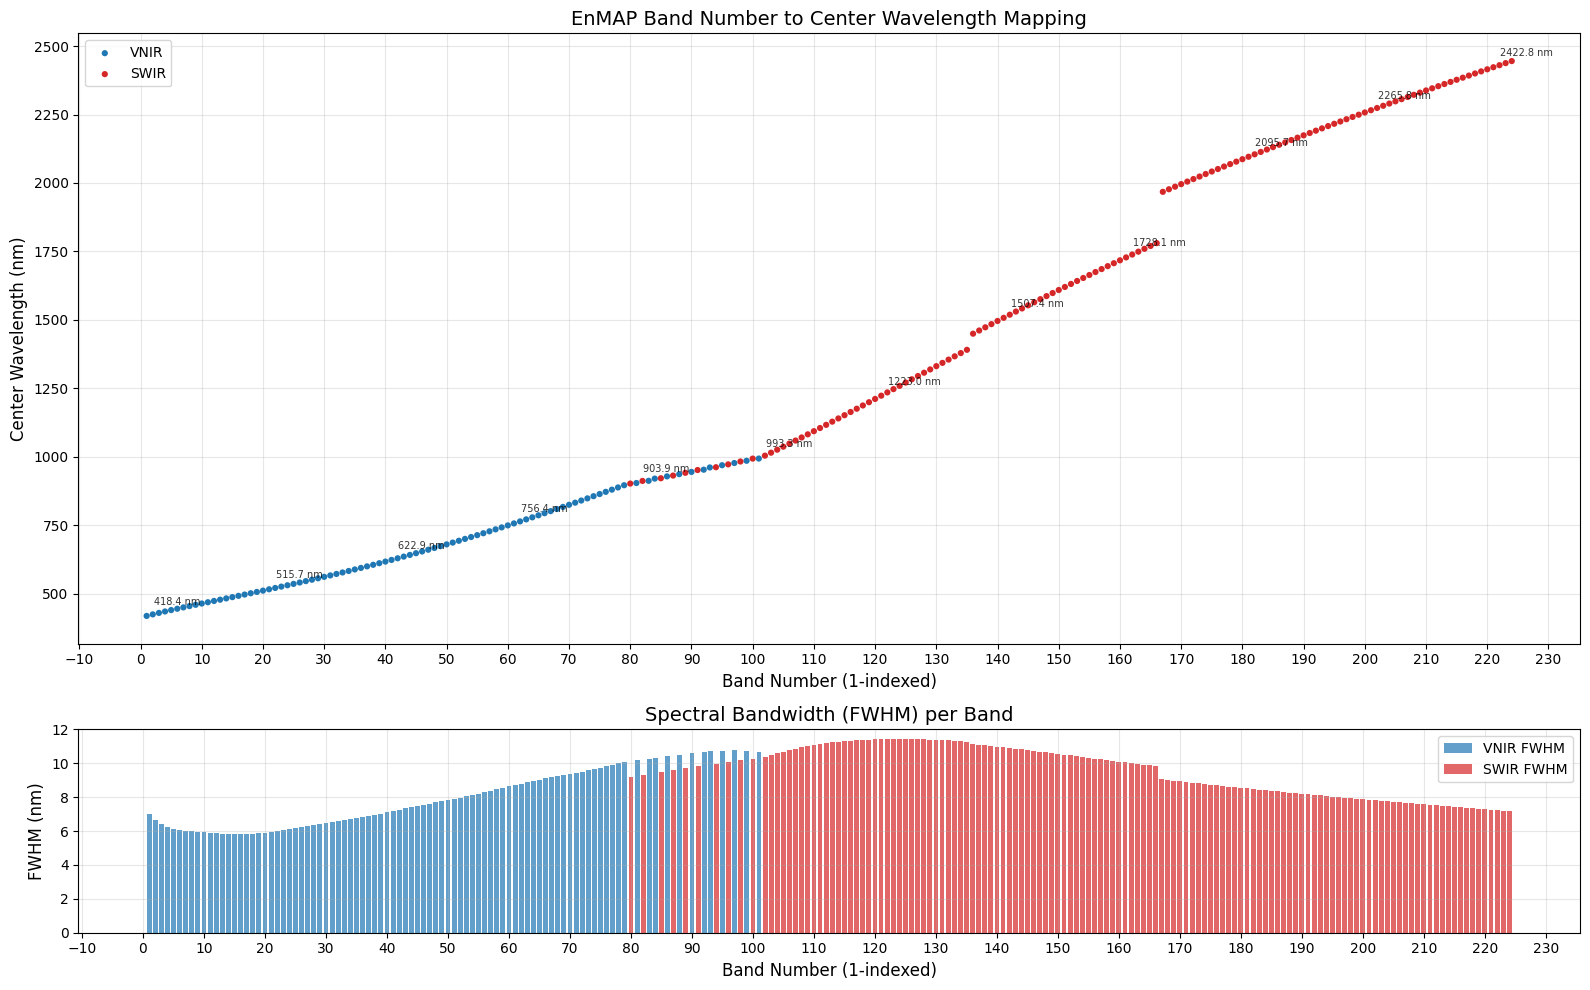

In [7]:
v0 = first_vendable
wavelengths = np.array(v0.band_cw_order)
fwhm = np.array(v0.band_fwhm_order)
families = v0.spectral_family_order
band_numbers = np.arange(1, len(wavelengths) + 1)

is_vnir = np.array([f == SpectralFamily.VNIR for f in families])
is_swir = ~is_vnir

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={"height_ratios": [3, 1]})

# --- Top panel: wavelength vs band number ---
ax1.scatter(band_numbers[is_vnir], wavelengths[is_vnir],
            c="#1f77b4", s=20, label="VNIR", zorder=3, edgecolors="none")
ax1.scatter(band_numbers[is_swir], wavelengths[is_swir],
            c="#d62728", s=20, label="SWIR", zorder=3, edgecolors="none")

# Annotate every 20th band with its exact wavelength
for idx in range(0, len(wavelengths), 20):
    ax1.annotate(f"{wavelengths[idx]:.1f} nm",
                 xy=(band_numbers[idx], wavelengths[idx]),
                 xytext=(5, 8), textcoords="offset points",
                 fontsize=7, color="black", alpha=0.8)

ax1.set_xlabel("Band Number (1-indexed)", fontsize=12)
ax1.set_ylabel("Center Wavelength (nm)", fontsize=12)
ax1.set_title("EnMAP Band Number to Center Wavelength Mapping", fontsize=14)
ax1.legend(fontsize=10)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax1.grid(axis="both", alpha=0.3)

# --- Bottom panel: FWHM per band ---
ax2.bar(band_numbers[is_vnir], fwhm[is_vnir], color="#1f77b4", alpha=0.7, label="VNIR FWHM")
ax2.bar(band_numbers[is_swir], fwhm[is_swir], color="#d62728", alpha=0.7, label="SWIR FWHM")
ax2.set_xlabel("Band Number (1-indexed)", fontsize=12)
ax2.set_ylabel("FWHM (nm)", fontsize=12)
ax2.set_title("Spectral Bandwidth (FWHM) per Band", fontsize=14)
ax2.legend(fontsize=10)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax2.grid(axis="both", alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
for b,i, w in zip(band_indices, pct, wavelengths):
    print(b,i, w)

0 74.62790874104248 418.416
1 74.32952851938862 424.043
2 74.47894365300715 429.457
3 74.77809538137505 434.686
4 74.62778015659015 439.757
5 74.77809538137505 444.699
6 74.4781721462931 449.539
7 74.32650678475864 454.306
8 74.77809538137505 459.031
9 74.47881506855481 463.73
10 74.62900170888737 468.411
11 74.0292838231758 473.08
12 74.77809538137505 477.744
13 74.62790874104248 482.411
14 74.32631390808012 487.087
15 74.77809538137505 491.78
16 74.77809538137505 496.497
17 74.77809538137505 501.243
18 74.47482895053228 506.02
19 74.77809538137505 510.828
20 74.77809538137505 515.672
21 74.62906600111354 520.55
22 74.77809538137505 525.467
23 74.62816590994717 530.424
24 74.62816590994717 535.422
25 74.47965086749501 540.463
26 74.62649431206675 545.551
27 74.18094918471027 550.687
28 74.77809538137505 555.873
29 74.62970892337523 561.112
30 74.62919458556588 566.405
31 74.47939369859033 571.756
32 74.77809538137505 577.166
33 74.17895612569902 582.636
34 74.77809538137505 588.171
35

## 4. Full band wavelength reference table

Every band with its number, center wavelength, FWHM, and detector family.

In [ ]:
import pandas as pd

rows = []
for i in range(len(wavelengths)):
    rows.append({
        "Band #": i + 1,
        "Wavelength (nm)": round(wavelengths[i], 2),
        "FWHM (nm)": round(fwhm[i], 2),
        "Detector": "VNIR" if is_vnir[i] else "SWIR",
    })

df_bands = pd.DataFrame(rows)
df_bands.style.set_caption("EnMAP L2A Band Wavelength Reference")